In [1]:
import os
import pandas as pd
import pprint as pp
import random
import codenet_reader  # functions for reading data from codenet
import transformers

In [2]:
# Functions for processing solutions of a problem
def process_pid(pid: str, data: list[pd.DataFrame], tokenizer, random_state: int = 42):
    MIN_SOLUTIONS = 400
    NUM_ACCEPTED = 200
    NUM_REJECTED = 100

    num_python_solutions = len(codenet_reader.python_solutions(pid))
    if num_python_solutions < MIN_SOLUTIONS:
        return

    df = codenet_reader.init_metadata_df(pid)
    df = df[df["status"].isin({"Accepted", "Wrong Answer"})]
    
    if df is None:
        return
    
    df["code"] = df.apply(lambda row: codenet_reader.read_solution_file(pid, row["submission_id"]), axis=1)
    
    # Filter solutions that are too short or too long
    if tokenizer:
        df["num_tokens"] = df["code"].apply(lambda x: len(tokenizer.encode(x)))
        df = df[(df["num_tokens"] >= 5) & (df["num_tokens"] < 256)]
    
    if df.shape[0] < MIN_SOLUTIONS:
        return
    
    df_accepted = df[df["status"] == "Accepted"]
    df_rejected = df[df["status"] != "Accepted"]
    hardness = df_rejected.shape[0] / df.shape[0]
    
    if df_accepted.shape[0] < NUM_ACCEPTED:
        return
    if df_rejected.shape[0] < NUM_REJECTED:
        return
    
    print(f"{pid}: Sampling from {df.shape[0]:04d} code snippets.", f"Hardness: {hardness:.4f}")
    # Sample accepted and rejected solutions
    df = pd.concat([
        df_accepted.sample(NUM_ACCEPTED, random_state=random_state),
        df_rejected.sample(NUM_REJECTED, random_state=random_state)
    ], ignore_index=True)
    
    # Aggregate data
    data.append(df)
    return hardness

In [3]:
def test():
    data = []
    process_pid("p03200", data, None)
    #process_pid('p01701', data)
    df = pd.concat(data, ignore_index=True)
    pp.pp(df)

In [4]:
test()

p03200: Sampling from 0715 code snippets. Hardness: 0.1441
    problem_id submission_id        status  \
0       p03200    s238158355      Accepted   
1       p03200    s975745730      Accepted   
2       p03200    s514841881      Accepted   
3       p03200    s392218726      Accepted   
4       p03200    s113895025      Accepted   
..         ...           ...           ...   
295     p03200    s085233829  Wrong Answer   
296     p03200    s874994991  Wrong Answer   
297     p03200    s419752183  Wrong Answer   
298     p03200    s270228209  Wrong Answer   
299     p03200    s593576290  Wrong Answer   

                                                  code  
0    S = input()\nn = S.count('W')\nprint(sum([i fo...  
1    s=input()\nn=len(s)\nb_cnt=s.count("B")\nans=0...  
2    S = input()\n\nans = 0\nnum = 0\nfor i in rang...  
3    from scipy.misc import comb\ns = input()\nn = ...  
4    S=input()\ncount=0\nans=0\nfor i in range(len(...  
..                                            

In [5]:
# Reading data
RANDOM_SEED = 42
SAMPLE_SIZE = 4000  # Sample 500 problems
random.seed(RANDOM_SEED)

tokenizer = transformers.AutoTokenizer.from_pretrained("microsoft/codebert-base")

_pids = os.listdir(codenet_reader.DATA_PATH)
_pids = random.sample(_pids, k=min(SAMPLE_SIZE, len(_pids)))

print("Starting...")
print(f"Processing {len(_pids)} problems.")

_pid_hardness = {}
data = []
for _pid in _pids:
    hardness = process_pid(_pid, data, tokenizer, random_state=RANDOM_SEED)
    if hardness is not None: _pid_hardness[_pid] = hardness

print("Data gathered.")

df = pd.concat(data, ignore_index=True)
df = df.drop_duplicates(subset=["submission_id"])
pp.pp(df)

print("DONE")

Token indices sequence length is longer than the specified maximum sequence length for this model (607 > 512). Running this sequence through the model will result in indexing errors


Starting...
Processing 4000 problems.
p03711: Sampling from 0809 code snippets. Hardness: 0.1607
p03145: Sampling from 1203 code snippets. Hardness: 0.1762
p03408: Sampling from 1072 code snippets. Hardness: 0.1334
p03087: Sampling from 1098 code snippets. Hardness: 0.2140
p03146: Sampling from 1183 code snippets. Hardness: 0.2418
p03030: Sampling from 1283 code snippets. Hardness: 0.1528
p03486: Sampling from 1451 code snippets. Hardness: 0.2543
p02660: Sampling from 1428 code snippets. Hardness: 0.6653
p02866: Sampling from 0781 code snippets. Hardness: 0.6953
p02582: Sampling from 4629 code snippets. Hardness: 0.2921
p03759: Sampling from 0958 code snippets. Hardness: 0.1597
p02748: Sampling from 1866 code snippets. Hardness: 0.1367
p04044: Sampling from 1708 code snippets. Hardness: 0.0814
p02719: Sampling from 6543 code snippets. Hardness: 0.3570
p02910: Sampling from 1387 code snippets. Hardness: 0.2069
p03219: Sampling from 0941 code snippets. Hardness: 0.1201
p03719: Sampling f

In [6]:
df_problem_counts = df.groupby("problem_id")["status"].value_counts().unstack(fill_value=0)
df_problem_counts

status,Accepted,Wrong Answer
problem_id,,
p02546,200,100
p02547,200,100
p02548,200,100
p02552,200,100
p02553,200,100
...,...,...
p04033,200,100
p04034,200,100
p04043,200,100


In [7]:
df_problem_hardness = pd.DataFrame.from_dict(_pid_hardness, orient="index", columns=["hardness"])
df_problem_hardness

,hardness
p03711,0.160692
p03145,0.176226
p03408,0.133396
p03087,0.214026
p03146,0.241758
...,...
p03001,0.449024
p02963,0.627451
p02995,0.427460
p02684,0.654372


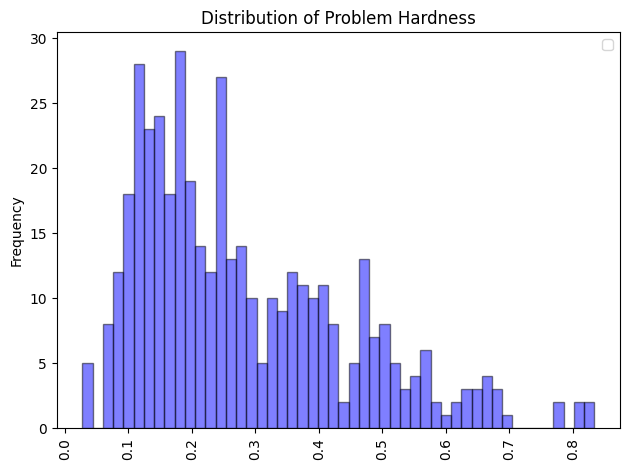

In [10]:
import matplotlib.pyplot as plt

ax = df_problem_hardness.sort_values(by="hardness", ascending=True).plot(
    kind="hist",
    bins=50,
    alpha=0.5,
    color='blue',
    edgecolor='black',
)
ax.legend([])

plt.title("Distribution of Problem Hardness")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [9]:
# Exporting
EXPORTED_FILE_NAME = "output.csv"

df[["problem_id","submission_id","status","code"]].to_csv(path_or_buf=EXPORTED_FILE_NAME, index=False)